# Manual Day — Neural Networks

Closed-agent, ~60 min. **Two problems — work through them in order; complete as many as time permits.** Complete every cell marked `# FILL IN`, then run the check cell.

## Mini-lecture: what a training loop is

Everything in machine learning that "learns" is one loop. You have a model with
**parameters**, a single number that says how wrong the model currently is, and a
rule for nudging the parameters to make that number smaller. Then you repeat.

Four steps per pass:

1. **Forward.** Push the inputs through the model with the current parameters to
   get predictions.
2. **Loss.** Compare predictions to targets and collapse that comparison into one
   number $L$. Smaller is better, by construction — you choose $L$ so that it is.
3. **Gradient.** Compute $\partial L/\partial\theta$ for each parameter $\theta$:
   which way is uphill, and how steeply.
4. **Update.** Step downhill,
   $\theta_{t+1} = \theta_t - \eta\,\dfrac{\partial L}{\partial\theta}\bigg|_{\theta_t}$,
   where $t$ counts the steps and the **learning rate** $\eta$ sets the stride.

Stripped of anything specific, that is:

```python
for epoch in range(num_epochs):
    pred   = model(x, params)        # 1. forward
    L      = loss(pred, y)           # 2. loss
    g      = gradient_of_L(params)   # 3. gradient
    params = params - lr * g         # 4. update
```

A deep neural network differs from today's straight line *only* in how complicated
step 1 is. Steps 2 through 4 are identical, which is why this loop is worth knowing
cold before anything fancier.

Vocabulary we will use all semester:

- **epoch** — one pass through the data. Our dataset is 25 points and every pass
  uses all of them, so here one epoch is exactly one gradient step. On large data
  you step on random subsets instead (**mini-batches**), which is where the
  *stochastic* in stochastic gradient descent comes from.
- **learning rate** $\eta$ — the stride length. Too small and you crawl; too large
  and you overshoot, so the loss oscillates or climbs. It is given to you below as
  `lr = 0.1`.
- **convergence** — the loss stops falling. That does *not* by itself mean you
  found the right answer: it may be the noise floor of the data (which is what
  happens below), a step size too large to settle, or a bad minimum.

**How to tell it is working.** Print the loss every few epochs and watch it fall.
If it rises, your gradient has the wrong sign or your learning rate is too big. If
it never moves, your gradient is zero — or, the classic, you computed the update
and never assigned it back to the parameters.

Finally, notice the shape: advance a state by a local rule, stop when a number
stops moving. That is the same skeleton as the power iteration you wrote last time,
as Euler integration and Jacobi relaxation in week 4, and as Metropolis later on.
Only the update line changes.

### How powerful is a single hidden layer?

Before building one, it is worth knowing what is on offer. Quoted verbatim from my
TASI lectures (*TASI Lectures on Physics for Machine Learning*, arXiv:2408.00082,
§2.1), the original version of the universal approximation theorem:

> **Theorem (Cybenko).** Let $f: \mathbb{R}^d \to \mathbb{R}$ be a continuous
> function on a compact set $K\subset \mathbb{R}^d$. Then for any $\epsilon>0$ there
> exists a neural network with a single hidden layer of the form
> $$\phi(x) = \sum_{i=1}^N \sum_{j=1}^d w_i^{(1)} \sigma(w_{ij}^{(0)}  x_j + b^{(0)}_i)+b^{(1)},$$
> $\theta = \{w_{ij}^{(0)}, w_i^{(1)}, b^{(0)}_i, b^{(1)}\}$, where
> $\sigma:\mathbb{R} \to \mathbb{R}$ is a non-polynomial non-linear activation
> function, such that
> $$\sup_{x\in K} |f(x) - \phi(x)| < \epsilon.$$

And the two caveats that matter here, also verbatim:

> The UAT is a powerful result, but it has some limitations. First, though the error
> $\epsilon$ does get better with $N$, it doesn't say how many neurons are needed.
> Second, it doesn't say how to train the network: though there is a point
> $\theta^*$ in parameter space that is a good approximation to any $f$, existence
> doesn't imply that we can find it, which is a question of learning dynamics.

That second caveat is why the rest of today is the loop. The theorem hands you
*existence*; gradient descent is the only way you actually go and find $\theta^*$.
Problem 3 builds exactly the architecture in the theorem — one hidden layer, with
$\tanh$ in place of Cybenko's sigmoid — on a target no straight line can fit.

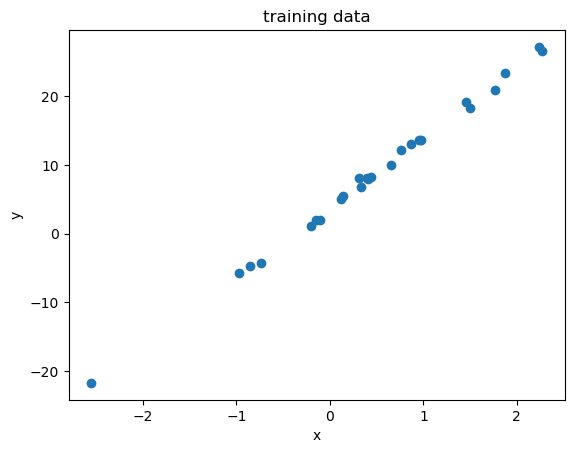

In [105]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)          # reproducible data for grading

# --- data: noise around the line  y = 10*x + 4  (lifted from lecture) ---
num_points = 25
xs = np.random.normal(size=(num_points, 1))
noise = np.random.normal(scale=.5, size=(num_points, 1))
ys = 10 * xs + 4 + noise

# --- hyperparameters (GIVEN) ---
m, b = 0.0, 0.0            # parameters, initialized at the origin
lr = 0.1                   # learning rate
num_epochs = 50            # gradient-descent steps

plt.scatter(xs, ys); plt.xlabel("x"); plt.ylabel("y"); plt.title("training data");

## Problem 1 — Linear regression by hand-derived gradient

## The problem

The simplest possible neural network is a straight line, $f(x) = m\,x + b$, a
function with two parameters. We fit it by **gradient descent** on the
mean-squared error

$$L(m,b) = \frac{1}{N}\sum_i \big(y_i - (m x_i + b)\big)^2 .$$

Differentiate it by hand — this is the whole point, **no autodiff, no jax** — to
get $\partial L/\partial m$ and $\partial L/\partial b$, then descend:

$$m_{t+1} = m_t - \eta\,\frac{\partial L}{\partial m}\bigg|_{t},
\qquad
b_{t+1} = b_t - \eta\,\frac{\partial L}{\partial b}\bigg|_{t},$$

where $t$ is the epoch and the derivatives are evaluated at $(m_t, b_t)$.

Not sure your derivation is right? That is what Problem 2 is for — it checks these
derivatives numerically. If it fails, come back and fix this one.

**Known answer:** the data was generated from $y = 10x + 4$, so after training
you should recover $m \approx 10$ and $b \approx 4$, with the MSE decreasing
monotonically toward the noise floor.

In [106]:
num_epochs

50

In [107]:
# FILL IN: predictions, your two hand-derived gradients, and the descent step
losses = []
for epoch in range(num_epochs + 1):
    #print("hello")
    f = m * xs + b        # predictions of the current line
    dLdm = -2 * np.mean(xs*(ys - f))   # dL/dm
    dLdb = -2 * np.mean(ys - f)  # dL/db
    m = m - lr * dLdm
    b = b - lr * dLdb

    # print(b)
    # print(m)
    
    # ... then step m and b downhill, using the learning rate lr

    losses.append(np.mean((ys - f) ** 2))
    if epoch % 10 == 0:
        print(epoch,losses[-1],m,b)
     
        # print(f"epoch {epoch:2d}: MSE={losses[-1]:.4f}  m={m:.3f}  b={b:.3f}")

0 193.67665822145665 3.15488429370922 1.730942183975553
10 0.5503073263631564 9.779417048459424 4.191911779944613
20 0.27357816187949685 10.092636497276953 3.924997970680015
30 0.26101388375458234 10.146342337676241 3.8492446194569268
40 0.26032722087577803 10.158594197399948 3.831316109957705
50 0.2602896583517619 10.161454859729846 3.8271195267056846


In [108]:
m.shape

()

final parameters:  m = 10.161,  b = 3.827
MSE trend:  193.677  ->  0.260   (decreasing: OK)
All checks passed.


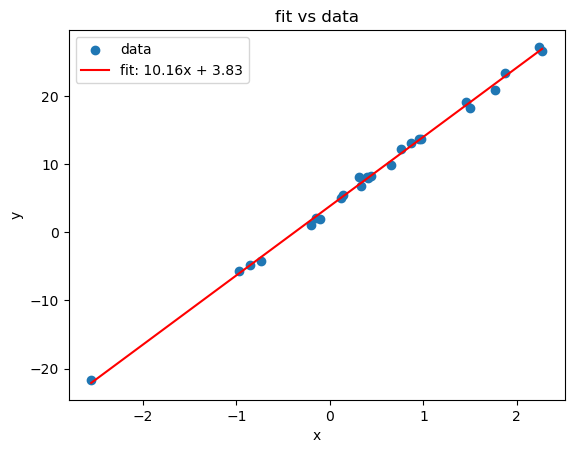

In [109]:
# --- CHECK (given): do not edit ---
print(f"final parameters:  m = {m:.3f},  b = {b:.3f}")
assert abs(m - 10.0) < 1.0, f"expected m ~ 10, got {m:.3f}"
assert abs(b - 4.0)  < 1.0, f"expected b ~ 4,  got {b:.3f}"

# MSE must be trending down (compare start vs end)
assert losses[-1] < losses[0], "MSE did not decrease"
print(f"MSE trend:  {losses[0]:.3f}  ->  {losses[-1]:.3f}   (decreasing: OK)")

# fit vs data
xline = np.linspace(xs.min(), xs.max(), 100).reshape(-1, 1)
plt.scatter(xs, ys, label="data")
plt.plot(xline, m * xline + b, "r-", label=f"fit: {m:.2f}x + {b:.2f}")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("fit vs data")
print("All checks passed.")

## Problem 2 — Gradient check by finite differences

Autodiff is convenient, but you should be able to confirm a gradient is correct
without it. A model-agnostic sanity check is the **central finite difference**:
perturb one parameter by a small step $h$ and measure how the loss responds,

$$\frac{\partial L}{\partial m} \approx \frac{L(m+h,\,b) - L(m-h,\,b)}{2h},
\qquad
\frac{\partial L}{\partial b} \approx \frac{L(m,\,b+h) - L(m,\,b-h)}{2h}.$$

Using the same data $y = 10x + 4 + \text{noise}$ and the loss
$L(m,b) = \text{mean}\big((y-(mx+b))^2\big)$, estimate the gradient numerically
at the test point $(m,b) = (3.0,\,1.0)$ with $h = 10^{-5}$.

**Known answer:** the numeric gradient must match the analytic gradient **you
derived in Problem 1**, to a relative error below $10^{-4}$.

In [116]:
# FILL IN: central finite-difference estimate of dL/dm and dL/db at (m,b)=(3.0,1.0)
m0, b0 = 3.0, 1.0     # test point (GIVEN)
h = 1e-5              # finite-difference step (GIVEN)

# Write the loss as a function of (m, b), then perturb one argument at a time.
# L = np.mean(ys - f)
# f = m * xs + b
# f(+h) = m * xs + b, L(m+h, b) = np.mean(ys - f(+h)) **2 = np.mean(ys - ((m + h) * xs + b)) **2
# f(-h) = m * xs + b, L(m-h, b) = np.mean(ys - f(+h)) **2 = np.mean(ys - ((m - h) * xs + b)) **2
# f(b+h) = m * xs + (b+h), f(b - h) = m * xs + (b-h)
# L(m, b+h) = np.mean(ys - f(+h)) **2 = np.mean(ys - (m * xs + (b + h))) **2


num_dLdm =  (np.mean((ys - ((m0 + h) * xs + b0))**2) - np.mean((ys - ((m0 - h) * xs + b0))**2)) / (2*h)    # numeric dL/dm
num_dLdb = (np.mean((ys - (m0 * xs + (b0 + h)))**2) - np.mean((ys - (m0 * xs + (b0 - h)))**2)) / (2*h)        # numeric dL/db

print(f"numeric gradient:  dL/dm = {num_dLdm:.6f},  dL/db = {num_dLdb:.6f}")

numeric gradient:  dL/dm = -22.358366,  dL/db = -12.458379


In [117]:
# --- CHECK (given): do not edit ---
f = m0 * xs + b0
ana_dLdm = -2 * np.mean((ys - f) * xs)    # analytic dL/dm at the test point
ana_dLdb = -2 * np.mean(ys - f)           # analytic dL/db at the test point
print(f"analytic gradient: dL/dm = {ana_dLdm:.6f},  dL/db = {ana_dLdb:.6f}")

rel_m = abs(num_dLdm - ana_dLdm) / abs(ana_dLdm)
rel_b = abs(num_dLdb - ana_dLdb) / abs(ana_dLdb)
print(f"relative error:    dL/dm: {rel_m:.2e},  dL/db: {rel_b:.2e}")

assert rel_m < 1e-4, f"dL/dm off: rel error {rel_m:.2e}"
assert rel_b < 1e-4, f"dL/db off: rel error {rel_b:.2e}"
print("All checks passed.")

analytic gradient: dL/dm = -22.358366,  dL/db = -12.458379
relative error:    dL/dm: 2.07e-11,  dL/db: 9.27e-11
All checks passed.


## Problem 3 — Challenge: one hidden layer, backprop by hand

Take the UAT up on its offer. The target is $y = x^2$ on $[-1,1]$, chosen because
**a line cannot bend**: no choice of $(m,b)$ fits it, and the best straight line
leaves a mean-squared error you can work out in advance — the variance of $x^2$ over
the interval, $\tfrac15 - \tfrac19 = \tfrac{4}{45} \approx 0.0889$ (0.0946 on the
64-point grid used below). That is the floor you have to beat.

The model is the theorem's architecture at width $N=8$ with $\sigma=\tanh$:

$$h = \tanh\big(x\,w^{(0)} + b^{(0)}\big), \qquad \phi = h\,w^{(1)} + b^{(1)}.$$

Your job is the **backward pass**. With $L = \frac1N\sum_i (y_i-\phi_i)^2$, start
from $\partial L/\partial\phi$ and push it back through the layer by the chain rule.
One useful fact: $\tanh' = 1-\tanh^2$, so the hidden activations you already
computed hand you the derivative for free — no second evaluation. Four gradients
come out, two for the output layer and two for the hidden layer. Forward pass,
initialization, and training loop are given; you wrote that loop in Problem 1.

**Known answers.**

1. Your gradients must match central finite differences to a relative error below
   $10^{-6}$. That is Problem 2's method used the way it is used in practice: to
   confirm a hand-derived gradient *before* trusting anything built on it. A wrong
   derivation fails here, loudly.
2. After 3000 epochs at `lr = 0.2` the network reaches MSE $\approx 2.4\times10^{-4}$
   — roughly 390x below the linear floor — and the fit visibly bends.

If there is time afterwards, rerun with `lr = 0.5`. It diverges to `nan`, which is
the learning-rate warning from the mini-lecture with a concrete address.

In [ ]:
# GIVEN — data, architecture, initialization, forward pass, loss.
N, H = 64, 8
xs2 = np.linspace(-1, 1, N).reshape(-1, 1)
ys2 = xs2 ** 2                              # a line cannot bend

rng = np.random.default_rng(0)
W1 = rng.normal(size=(1, H)); b1 = np.zeros(H)     # hidden layer
W2 = rng.normal(size=(H, 1)); b2 = 0.0             # output layer
init = (W1.copy(), b1.copy(), W2.copy(), b2)       # kept for the gradient check
lr2, epochs2 = 0.2, 3000

def forward(W1, b1, W2, b2):
    h = np.tanh(xs2 @ W1 + b1)
    return h, h @ W2 + b2

def mse(W1, b1, W2, b2):
    return np.mean((ys2 - forward(W1, b1, W2, b2)[1]) ** 2)

In [ ]:
# FILL IN: the backward pass — return the four gradients in this order.
def grads(W1, b1, W2, b2):
    h, phi = forward(W1, b1, W2, b2)
    dLdphi = ...        # dL/dphi
    dW2 = ...           # output layer
    db2 = ...
    dz = ...            # the signal arriving at the hidden pre-activation
    dW1 = ...           # hidden layer
    db1 = ...
    return dW1, db1, dW2, db2

In [ ]:
# GIVEN — the Problem 1 loop again, now over four parameters.
W1, b1, W2, b2 = init[0].copy(), init[1].copy(), init[2].copy(), init[3]
history = []
for epoch in range(epochs2):
    gW1, gb1, gW2, gb2 = grads(W1, b1, W2, b2)
    W1 -= lr2 * gW1
    b1 -= lr2 * gb1
    W2 -= lr2 * gW2
    b2 -= lr2 * gb2
    history.append(mse(W1, b1, W2, b2))
    if epoch % 500 == 0:
        print(f"epoch {epoch:4d}: MSE = {history[-1]:.3e}")
print(f"epoch {epochs2:4d}: MSE = {history[-1]:.3e}")

In [ ]:
# CHECK — do not edit
# 1) does the hand-derived gradient agree with finite differences? (Problem 2's tool)
P0 = [init[0].copy(), init[1].copy(), init[2].copy(), init[3]]
gW1, gb1, gW2, gb2 = grads(*P0)
hstep, worst = 1e-6, 0.0
for label, analytic, slot, idx in [("W1[0,3]", gW1[0, 3], 0, (0, 3)),
                                   ("b1[2]",   gb1[2],   1, (2,)),
                                   ("W2[5,0]", gW2[5, 0], 2, (5, 0))]:
    up, dn = P0[slot].copy(), P0[slot].copy()
    up[idx] += hstep
    dn[idx] -= hstep
    Pu, Pd = list(P0), list(P0)
    Pu[slot], Pd[slot] = up, dn
    numeric = (mse(*Pu) - mse(*Pd)) / (2 * hstep)
    rel = abs(numeric - analytic) / abs(analytic)
    worst = max(worst, rel)
    print("dL/d%-8s analytic %+.8f   numeric %+.8f   rel err %.1e"
          % (label, analytic, numeric, rel))
assert worst < 1e-6, "backprop disagrees with finite differences — the derivation is wrong"

# 2) did it beat the best straight line?
A = np.hstack([xs2, np.ones_like(xs2)])
coef, *_ = np.linalg.lstsq(A, ys2, rcond=None)
floor = np.mean((ys2 - A @ coef) ** 2)
print("\nfinal MSE      = %.3e" % history[-1])
print("straight line  = %.4f   (Var[x^2] = 4/45 = %.4f)" % (floor, 4 / 45))
print("ratio          = %.0fx below the linear floor" % (floor / history[-1]))
assert history[-1] < floor / 50, "the network did not clearly beat a straight line"
print("OK")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))
a1.plot(xs2, ys2, "k-", lw=2, label="target  y = x^2")
a1.plot(xs2, forward(W1, b1, W2, b2)[1], "r--", lw=2, label="network")
a1.plot(xs2, A @ coef, "b:", lw=2, label="best line")
a1.legend(); a1.set_xlabel("x"); a1.set_ylabel("y"); a1.set_title("one hidden layer, 8 units")
a2.semilogy(history); a2.axhline(floor, ls=":", c="b", label="linear floor")
a2.set_xlabel("epoch"); a2.set_ylabel("MSE"); a2.legend(); a2.set_title("training")
plt.tight_layout();